In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

In [2]:
import numpy as np
from aeon.classification.interval_based import RSTSF
from sklearn.metrics import accuracy_score
from tscglue.models import LokyStackerV7, LokyStackerV7SoftFilterRidge, LokyStackerV10FM, TSCGlue, LokyStackerV9Base, LokyStackerV10Base, LokyStackerV10TabICL
from tscglue import utils, data_loader
import polars as pl
from sklearn.metrics import log_loss, roc_auc_score


In [3]:
dataset = "Worms"
# dataset = 'Car'
dataset = 'HandOutlines'
#dataset = 'Trace'
#dataset = 'SwedishLeaf'
#dataset = 'Meat'
# dataset='ACSF1'
dataset='MedicalImages'
X_train, y_train, X_test, y_test = data_loader.load_fold(dataset, 19)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(381, 1, 99) (381,) (760, 1, 99) (760,)


In [4]:
seed = 2683

In [5]:
m = LokyStackerV10FM(random_state=seed, n_jobs=16, keep_features=True, verbose=10, n_repetitions=3)

In [6]:
m.fit(X_train, y_train)

[0.00s] Starting fit, run_dir=tscglue_runs/9af3c1b92ce54173, n_jobs=16
[0.00s] Saved X and y to disk in 0.00s
[5.32s] Fitted transformer multirocket_s_1675711793 in 5.26s
[8.72s] Fitted transformer hydra_s_2109509380 in 3.40s
[12.18s] Fitted transformer quant in 3.47s
[16.76s] Fitted transformer rdst_s_1973074453 in 4.58s
[23.27s] Fitted transformer mantis in 6.50s
[29.53s] Fitted transformer chronos2 in 6.26s
[33.67s] Computed multirocket_s_1675711793 features (381, 49728) (144.55 MB) in 4.1444s
[37.33s] Computed hydra_s_2109509380 features (381, 4096) (11.91 MB) in 3.6581s
[40.92s] Computed quant features (381, 1026) (2.98 MB) in 3.5944s
[46.31s] Computed rdst_s_1973074453 features (381, 30000) (87.20 MB) in 5.3881s
[55.84s] Computed mantis features (381, 512) (1.49 MB) in 9.5234s
[66.62s] Computed chronos2 features (381, 1536) (4.46 MB) in 10.7861s
[66.64s] Starting training with 16 workers for 150 models


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, whic

[68.78s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.1141s for f-15 (4.26 MB)
[68.80s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.1240s for f-10 (4.26 MB)
[68.80s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.1298s for f-4 (4.26 MB)
[68.82s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.1545s for f-1 (4.26 MB)
[68.83s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.1552s for f-9 (4.26 MB)
[68.88s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.2068s for f-5 (4.26 MB)
[68.89s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.2153s for f-11 (4.26 MB)
[68.91s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.2388s for f-14 (4.26 MB)
[68.93s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.2648s for f-6 (4.26 MB)
[68.94s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.2627s for f-12 (4.26 MB)
[68.94s] Trained multirockethydra-bestk-p-ridgecv_s_947394068 in 2.2693s for f-13 (4.

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(


[84.15s] Starting stacking training with 10 workers for 10 models
[84.17s] Trained probability-ridgecv in 0.0140s for f-0 (0.01 MB)
[84.17s] Trained probability-ridgecv in 0.0146s for f-2 (0.01 MB)
[84.17s] Trained probability-ridgecv in 0.0139s for f-8 (0.01 MB)
[84.18s] Trained probability-ridgecv in 0.0149s for f-5 (0.01 MB)
[84.18s] Trained probability-ridgecv in 0.0152s for f-7 (0.01 MB)
[84.18s] Trained probability-ridgecv in 0.0154s for f-6 (0.01 MB)
[84.18s] Trained probability-ridgecv in 0.0145s for f-9 (0.01 MB)
[84.18s] Trained probability-ridgecv in 0.0203s for f-1 (0.01 MB)
[84.19s] Trained probability-ridgecv in 0.0224s for f-3 (0.01 MB)
[84.19s] Trained probability-ridgecv in 0.0221s for f-4 (0.01 MB)
[84.19s] Completed training for model probability-ridgecv
[84.20s] OOF acc (stack) probability-ridgecv: 0.821522309711286
[84.20s] Fit complete
[85.42s] Executor shutdown complete


,random_state,2683
,k_folds,10
,n_jobs,16
,keep_features,True
,verbose,10
,model_names,None
,n_repetitions,3


In [7]:
y_pred = m.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy on {dataset}: {acc}")

[0.00s] Starting prediction
[5.85s] Computed multirocket_s_1675711793 features (760, 49728) (288.34 MB) in 5.8002s
[10.05s] Computed hydra_s_2109509380 features (760, 4096) (23.75 MB) in 4.2036s
[13.64s] Computed quant features (760, 1026) (5.95 MB) in 3.5824s
[20.36s] Computed rdst_s_1973074453 features (760, 30000) (173.95 MB) in 6.7191s
[31.57s] Computed mantis features (760, 512) (2.97 MB) in 11.2101s
[45.71s] Computed chronos2 features (760, 1536) (8.91 MB) in 14.1456s
[45.71s] Computed and saved features for prediction
[45.71s] Starting prediction with 16 workers for 150 first-level models
[46.99s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.2155s
[47.12s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.2332s
[47.23s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.1793s
[47.27s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.1925s
[47.31s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.2327s
[47.33s] Predicted mul

In [8]:
proba = m.predict_proba(X_test)
classes = list(m.classes_)

print(f"Log-loss: {log_loss(y_test, proba, labels=classes):.4f}")
# print(f"AUC (OvR): {roc_auc_score(y_test, proba, multi_class='ovr', labels=classes):.4f}")

[0.00s] Starting prediction
[6.22s] Computed multirocket_s_1675711793 features (760, 49728) (288.34 MB) in 6.1738s
[9.90s] Computed hydra_s_2109509380 features (760, 4096) (23.75 MB) in 3.6789s
[13.73s] Computed quant features (760, 1026) (5.95 MB) in 3.8383s
[20.35s] Computed rdst_s_1973074453 features (760, 30000) (173.95 MB) in 6.6158s
[31.05s] Computed mantis features (760, 512) (2.97 MB) in 10.7029s
[44.89s] Computed chronos2 features (760, 1536) (8.91 MB) in 13.8356s
[44.89s] Computed and saved features for prediction
[44.89s] Starting prediction with 16 workers for 150 first-level models
[45.95s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.0072s
[46.02s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.0053s
[46.83s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.0163s
[46.85s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.0435s
[46.86s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.1837s
[46.88s] Predicted mult

In [9]:
pl.DataFrame(m.neki)

index,model,level,class,probability
i64,str,i64,str,f64
13,"""multirockethydra-bestk-p-ridge…",0,"""1""",0.202101
13,"""multirockethydra-bestk-p-ridge…",0,"""10""",0.187738
13,"""multirockethydra-bestk-p-ridge…",0,"""2""",0.071113
13,"""multirockethydra-bestk-p-ridge…",0,"""3""",0.087326
13,"""multirockethydra-bestk-p-ridge…",0,"""4""",0.07094
…,…,…,…,…
345,"""probability-ridgecv""",1,"""5""",0.0
345,"""probability-ridgecv""",1,"""6""",0.0
345,"""probability-ridgecv""",1,"""7""",0.0


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 6 members, which is less than n_splits=10.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/petelin/TSCGlue/.venv/lib/python3.13/site-packa

[0.00s] Starting prediction


/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


[5.83s] Computed multirocket_s_1675711793 features (760, 49728) (288.34 MB) in 5.7878s
[10.03s] Computed hydra_s_2109509380 features (760, 4096) (23.75 MB) in 4.2016s
[13.66s] Computed quant features (760, 1026) (5.95 MB) in 3.6253s
[20.26s] Computed rdst_s_1973074453 features (760, 30000) (173.95 MB) in 6.6062s
[31.01s] Computed mantis features (760, 512) (2.97 MB) in 10.7490s
[44.89s] Computed chronos2 features (760, 1536) (8.91 MB) in 13.8719s
[44.89s] Computed and saved features for prediction
[44.89s] Starting prediction with 16 workers for 150 first-level models
[45.87s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 0.9433s
[46.36s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 0.9571s
[46.39s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 0.9730s
[46.45s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.1017s
[46.51s] Predicted multirockethydra-bestk-p-ridgecv_s_947394068 in 1.3832s
[46.59s] Predicted multirockethydra-bestk-p-ridgec

/home/petelin/TSCGlue/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


RidgeCV   OOF mean=0.8205 std=0.0021  test=0.8263
RF        OOF mean=0.8158 std=0.0052  test=0.8276
HGBT      OOF mean=0.7966 std=0.0093  test=0.8250
MLP       OOF mean=0.8150 std=0.0050  test=0.8368


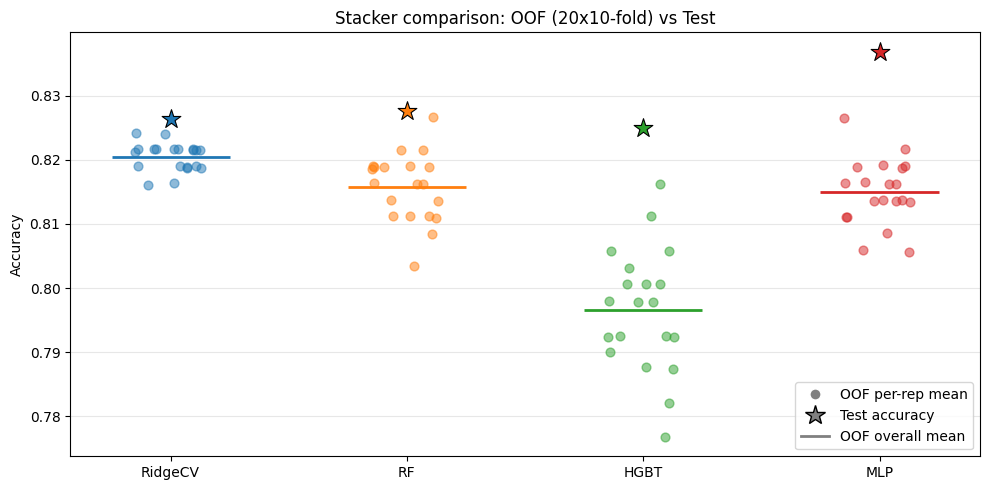

In [13]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Build probability matrix from level-0 neki predictions
df = pl.DataFrame(m.neki).filter(pl.col("level") == 0)
prob_matrix = df.pivot(on="class", index=["index", "model"], values="probability", aggregate_function='mean')
class_cols = [c for c in prob_matrix.columns if c not in ("index", "model")]
wide = prob_matrix.pivot(on="model", index="index", values=class_cols)
wide = wide.sort("index")
X_stack = wide.drop("index").to_numpy()

le = LabelEncoder()
y_enc = le.fit_transform(y_train)

stackers = {
    "RidgeCV": RidgeClassifierCV(alphas=np.logspace(-3, 3, 20)),
    "RF": RandomForestClassifier(n_estimators=200, n_jobs=-1),
    "HGBT": HistGradientBoostingClassifier(max_iter=200),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
}

N_REPEATS = 20
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=N_REPEATS, random_state=42)
results = {name: [] for name in stackers}

for fold_i, (tr_idx, val_idx) in enumerate(rskf.split(X_stack, y_enc)):
    rep = fold_i // 10
    for name, clf in stackers.items():
        clf_copy = clf.__class__(**clf.get_params())
        clf_copy.fit(X_stack[tr_idx], y_enc[tr_idx])
        acc = accuracy_score(y_enc[val_idx], clf_copy.predict(X_stack[val_idx]))
        results[name].append({"rep": rep, "fold": fold_i % 10, "acc": acc})

# Build test probability matrix
test_preds = m.predict_proba_per_model(X_test)
train_cols = wide.drop("index").columns

test_records = []
for model_name, proba_arr in test_preds.items():
    if model_name in m.stacking_models:
        continue
    classes_ = list(m.classes_)
    for i in range(proba_arr.shape[0]):
        for j, cls in enumerate(classes_):
            test_records.append({"index": i, "model": model_name, "level": 0, "class": str(cls), "probability": proba_arr[i, j]})

df_test = pl.DataFrame(test_records)
prob_matrix_test = df_test.pivot(on="class", index=["index", "model"], values="probability")
class_cols_test = [c for c in prob_matrix_test.columns if c not in ("index", "model")]
wide_test = prob_matrix_test.pivot(on="model", index="index", values=class_cols_test)
wide_test = wide_test.sort("index")
X_stack_test = wide_test.select(train_cols).to_numpy()
y_test_enc = le.transform(y_test)

# Test set accuracy
test_accs = {}
for name, clf in stackers.items():
    clf_final = clf.__class__(**clf.get_params())
    clf_final.fit(X_stack, y_enc)
    test_accs[name] = accuracy_score(y_test_enc, clf_final.predict(X_stack_test))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
names = list(stackers.keys())
x_positions = np.arange(len(names))

for i, name in enumerate(names):
    rdf = pl.DataFrame(results[name])
    per_rep = rdf.group_by("rep").agg(pl.col("acc").mean()).sort("rep")["acc"].to_numpy()
    # scatter all per-rep OOF accuracies
    jitter = np.random.default_rng(0).uniform(-0.15, 0.15, size=len(per_rep))
    ax.scatter(np.full_like(per_rep, i) + jitter, per_rep, alpha=0.5, s=40, zorder=3, label=f"{name} OOF reps" if i == 0 else None, color=f"C{i}")
    # mean OOF line
    ax.hlines(per_rep.mean(), i - 0.25, i + 0.25, colors=f"C{i}", linewidths=2, zorder=4)
    # test accuracy marker
    ax.scatter(i, test_accs[name], marker="*", s=200, color=f"C{i}", edgecolors="black", linewidths=0.8, zorder=5)
    print(f"{name:8s}  OOF mean={per_rep.mean():.4f} std={per_rep.std():.4f}  test={test_accs[name]:.4f}")

ax.set_xticks(x_positions)
ax.set_xticklabels(names)
ax.set_ylabel("Accuracy")
ax.set_title(f"Stacker comparison: OOF ({N_REPEATS}x10-fold) vs Test")
# custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="OOF per-rep mean"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=15, label="Test accuracy"),
    Line2D([0], [0], color="gray", linewidth=2, label="OOF overall mean"),
]
ax.legend(handles=legend_elements, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
